In [115]:
# ─────────────────────────────────────────────
# 환경 준비 — 라이브러리 불러오기 + 한글 폰트 + 시드 고정
# ─────────────────────────────────────────────
# 필요 시 아래 주석을 해제해 설치하세요.
# !pip install numpy pandas matplotlib seaborn -q

import platform
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")   # 학습 중 경고 메시지를 잠시 숨깁니다.

# 재현성: 같은 난수를 항상 같게 만들어 결과가 매번 동일하도록 고정합니다.
np.random.seed(42)

# 한글 폰트 설정 (그래프 안 글자가 깨지지 않도록 운영체제별로 분기)
system = platform.system()
if system == "Darwin":          # macOS
    plt.rcParams["font.family"] = "AppleGothic"
elif system == "Windows":       # Windows
    plt.rcParams["font.family"] = "Malgun Gothic"
else:                            # Linux 등
    plt.rcParams["font.family"] = "DejaVu Sans"

plt.rcParams["axes.unicode_minus"] = False   # 마이너스 부호 깨짐 방지
plt.rcParams["figure.figsize"] = (10, 5)
sns.set_style("whitegrid")

print("준비 완료! 라이브러리 버전을 확인합니다.")
print("numpy :", np.__version__)
print("pandas:", pd.__version__)

준비 완료! 라이브러리 버전을 확인합니다.
numpy : 2.4.6
pandas: 3.0.3


In [116]:
!pip install seaborn -q


In [117]:
# ─────────────────────────────────────────────
# 모두마켓 데이터 생성 — 이 셀 하나로 오늘 쓸 데이터가 모두 준비됩니다.
# (실제 현장처럼 '오염'을 일부러 심어 둡니다: 결측·이상치·표기 혼재·날짜 포맷 혼재·중복)
# ─────────────────────────────────────────────
np.random.seed(42)

# 1) 고객(customers)
n_customers = 300
customers = pd.DataFrame({
    "customer_id": [f"C{str(i).zfill(4)}" for i in range(1, n_customers + 1)],
    "age": np.random.normal(35, 9, n_customers).round().astype(int),
    "gender": np.random.choice(["M", "F"], n_customers),
    "region": np.random.choice(["서울", "경기", "부산", "인천", "대구"], n_customers),
    "membership": np.random.choice(["basic", "premium", "vip"], n_customers, p=[0.6, 0.3, 0.1]),
})
# 오염 심기: 나이 이상치, 결측, 지역/멤버십 표기 혼재
customers.loc[5, "age"] = 999          # 입력 실수로 보이는 이상치
customers.loc[10, "age"] = -3          # 음수 나이(불가능한 값)
customers.loc[[20, 21, 22], "gender"] = np.nan
customers.loc[30, "region"] = " 서울 "  # 앞뒤 공백
customers.loc[31, "region"] = "Seoul"   # 영문 표기 혼재
customers.loc[40, "membership"] = "VIP"  # 대소문자 혼재

# 2) 상품(products)
categories = ["패션", "뷰티", "식품", "가전", "도서"]
n_products = 40
products = pd.DataFrame({
    "product_id": [f"P{str(i).zfill(3)}" for i in range(1, n_products + 1)],
    "category": np.random.choice(categories, n_products),
    "price": np.random.choice([9900, 19900, 29900, 49900, 89900, 129900], n_products),
})

# 3) 주문(orders)
n_orders = 2000
order_customer = np.random.choice(customers["customer_id"], n_orders)
order_product = np.random.choice(products["product_id"], n_orders)
price_map = products.set_index("product_id")["price"]
quantity = np.random.choice([1, 1, 1, 2, 2, 3], n_orders)
amount = price_map.loc[order_product].values * quantity

orders = pd.DataFrame({
    "order_id": [f"O{str(i).zfill(5)}" for i in range(1, n_orders + 1)],
    "customer_id": order_customer,
    "product_id": order_product,
    "quantity": quantity,
    "amount": amount.astype(float),
    "channel": np.random.choice(["web", "app", "app ", "APP"], n_orders, p=[0.45, 0.45, 0.05, 0.05]),
})

# 날짜 포맷 혼재(문자열로 저장 — 일부러 통일하지 않음)
base_dates = pd.to_datetime("2025-01-01") + pd.to_timedelta(np.random.randint(0, 120, n_orders), unit="D")
date_strings = []
for i, d in enumerate(base_dates):
    if i % 3 == 0:
        date_strings.append(d.strftime("%Y-%m-%d"))
    elif i % 3 == 1:
        date_strings.append(d.strftime("%Y/%m/%d"))
    else:
        date_strings.append(d.strftime("%Y%m%d"))
orders["order_date"] = date_strings

# 오염 심기: 금액 결측, 수량 이상치, 중복 행
orders.loc[np.random.choice(n_orders, 35, replace=False), "amount"] = np.nan
orders.loc[7, "quantity"] = 100        # 비정상적으로 큰 주문 수량
orders = pd.concat([orders, orders.iloc[[0, 1]]], ignore_index=True)  # 중복 주문 2건

print("모두마켓 데이터 생성 완료")
print("customers:", customers.shape, "| products:", products.shape, "| orders:", orders.shape)

모두마켓 데이터 생성 완료
customers: (300, 5) | products: (40, 3) | orders: (2002, 7)


In [118]:
# 예제: 컬렉션 4종을 모두마켓 맥락으로 만들어 봅니다.
order_amounts = [19900, 29900, 9900, 19900]      # 리스트: 주문 금액들 (순서·중복 O)
store_location = (37.5665, 126.9780)             # 튜플: 본사 좌표 (수정 X)
regions_seen = {"서울", "경기", "부산", "서울"}    # 집합: 중복이 자동으로 사라짐
customer = {"id": "C0001", "age": 35, "region": "서울"}  # 딕셔너리: 이름표로 접근

print("리스트(주문 금액):", order_amounts, "| 합계:", sum(order_amounts))
print("튜플(본사 좌표):", store_location)
print("집합(등장한 지역):", regions_seen, "  ← '서울' 중복이 사라짐")
print("딕셔너리(고객):", customer["region"], "에 사는", customer["age"], "세 고객")

리스트(주문 금액): [19900, 29900, 9900, 19900] | 합계: 79600
튜플(본사 좌표): (37.5665, 126.978)
집합(등장한 지역): {'부산', '경기', '서울'}   ← '서울' 중복이 사라짐
딕셔너리(고객): 서울 에 사는 35 세 고객


In [119]:
# 스스로 해보자! (1)
# 아래 주석(#)을 지우고 빈칸(___)을 채운 뒤 실행해보세요.
my_customer = {
    "id": "C0099",
    "age": 47,
    "region": "서울",
    "is_premium": True,
}
print(my_customer["age"])


47


In [120]:
# 예제: 주문 총액(부가세 포함)을 계산하는 함수
def calc_total(price, quantity, vat_rate=0.1):
    # 가격 x 수량에 부가세를 더한 총액을 반환합니다.
    subtotal = price * quantity
    total = subtotal * (1 + vat_rate)
    return total

# 한 번 정의했으니 몇 번이든 재사용합니다.
print("19900원 2개 총액:", calc_total(19900, 2))
print("49900원 1개 총액:", calc_total(49900, 1))
print("9900원 3개 총액 :", calc_total(9900, 3))

19900원 2개 총액: 43780.0
49900원 1개 총액: 54890.00000000001
9900원 3개 총액 : 32670.000000000004


In [121]:
# 예제: lambda — 이름 없는 한 줄짜리 함수
# pandas에서 컬럼 변환할 때 자주 등장하므로 미리 맛만 봅니다.
to_won = lambda x: f"{x:,.0f}원"   # 숫자를 '19,900원' 형태 문자열로

amounts = [19900, 29900, 9900]
print([to_won(a) for a in amounts])   # 리스트의 각 값에 함수를 적용(리스트 컴프리헨션)

['19,900원', '29,900원', '9,900원']


In [122]:
# 예제: 고객을 표현하는 간단한 클래스
class Customer:
    def __init__(self, customer_id, age, is_premium):
        # __init__: 객체가 만들어질 때 처음 한 번 실행 — 데이터를 담아둡니다.
        self.customer_id = customer_id
        self.age = age
        self.is_premium = is_premium

    def discount_rate(self):
        # 메서드: 이 객체의 데이터를 사용하는 작업
        return 0.15 if self.is_premium else 0.05

# 붕어빵 틀(Customer)로 객체 두 개를 찍어냅니다.
c1 = Customer("C0001", 35, True)
c2 = Customer("C0002", 41, False)
print(c1.customer_id, "할인율:", c1.discount_rate())
print(c2.customer_id, "할인율:", c2.discount_rate())

C0001 할인율: 0.15
C0002 할인율: 0.05


In [123]:
# 예제: 리스트 vs NumPy 배열 — 같은 '전체에 1.1 곱하기'
py_list = [19900, 29900, 9900]
np_array = np.array([19900, 29900, 9900])

# 리스트는 곱하면 '반복'이 됩니다 (원하는 게 아님!)
print("리스트 * 2 →", py_list * 2)

# 배열은 모든 원소에 연산이 '전파'됩니다 (벡터화)
print("배열 * 1.1 →", np_array * 1.1)

리스트 * 2 → [19900, 29900, 9900, 19900, 29900, 9900]
배열 * 1.1 → [21890. 32890. 10890.]


In [124]:
# 예제: 배열 만들기 · 연산 · 집계
amounts = np.array([19900, 29900, 9900, 49900, 19900])

print("배열      :", amounts)
print("부가세 포함:", amounts * 1.1)        # 벡터화
print("합계      :", amounts.sum())
print("평균      :", amounts.mean())
print("표준편차  :", amounts.std().round(1))
print("최댓값    :", amounts.max())

# 브로드캐스팅: 배열 - 숫자 → 각 값에서 평균을 뺀 '편차'
deviation = amounts - amounts.mean()
print("평균과의 편차:", deviation)

배열      : [19900 29900  9900 49900 19900]
부가세 포함: [21890. 32890. 10890. 54890. 21890.]
합계      : 129500
평균      : 25900.0
표준편차  : 13564.7
최댓값    : 49900
평균과의 편차: [ -6000.   4000. -16000.  24000.  -6000.]


In [125]:
# 예제: 벡터화가 정말 빠른가? — 10만 개로 직접 비교
import time
big = np.random.randint(1000, 100000, 100_000)

# 방법 A) 파이썬 반복문
start = time.time()
result_loop = [x * 1.1 for x in big]
t_loop = time.time() - start

# 방법 B) NumPy 벡터화
start = time.time()
result_vec = big * 1.1
t_vec = time.time() - start

print(f"반복문    : {t_loop*1000:.1f} ms")
print(f"벡터화    : {t_vec*1000:.1f} ms")
print(f"→ 벡터화가 약 {t_loop/max(t_vec,1e-9):.0f}배 빠릅니다 (환경에 따라 다름)")

반복문    : 42.4 ms
벡터화    : 0.1 ms
→ 벡터화가 약 334배 빠릅니다 (환경에 따라 다름)


In [126]:
scores = np.array([72, 88, 95, 60, 78, 91, 55, 83])

print("평균:", scores.mean())
print("표준편차:", scores.std().round(1))
above = scores > scores.mean()
print(above.sum(), "명")


평균: 77.75
표준편차: 13.6
5 명


In [127]:
# 예제: 딕셔너리로 DataFrame 만들기 (Part 1의 딕셔너리가 재료!)
data = {
    "name": ["민준", "서연", "도윤", "지우"],
    "age": [35, 28, 41, 23],
    "region": ["서울", "부산", "서울", "인천"],
    "amount": [19900, 49900, 9900, 29900],
}
df_demo = pd.DataFrame(data)
display(df_demo)

print("한 열만 꺼내면 Series:", type(df_demo["age"]).__name__)
print("나이 평균:", df_demo["age"].mean())

,name,age,region,amount
0,민준,35,서울,19900
1,서연,28,부산,49900
2,도윤,41,서울,9900
3,지우,23,인천,29900


한 열만 꺼내면 Series: Series
나이 평균: 31.75


In [128]:
# 예제: 선택 · 필터 · 정렬 · 파생 컬럼 — 분석가가 가장 많이 하는 4가지
# 1) 열 선택
print("[열 선택] 이름과 금액\n", df_demo[["name", "amount"]], "\n")

# 2) 필터링(조건으로 행 고르기) — Part 3의 불리언 배열이 여기서 쓰입니다.
seoul = df_demo[df_demo["region"] == "서울"]
print("[필터] 서울 고객\n", seoul, "\n")

# 3) 정렬
print("[정렬] 금액 높은 순\n", df_demo.sort_values("amount", ascending=False), "\n")

# 4) 파생 컬럼 만들기 (부가세 포함 금액)
df_demo["amount_vat"] = df_demo["amount"] * 1.1
print("[파생 컬럼] amount_vat 추가\n", df_demo)

[열 선택] 이름과 금액
   name  amount
0   민준   19900
1   서연   49900
2   도윤    9900
3   지우   29900 

[필터] 서울 고객
   name  age region  amount
0   민준   35     서울   19900
2   도윤   41     서울    9900 

[정렬] 금액 높은 순
   name  age region  amount
1   서연   28     부산   49900
3   지우   23     인천   29900
0   민준   35     서울   19900
2   도윤   41     서울    9900 

[파생 컬럼] amount_vat 추가
   name  age region  amount  amount_vat
0   민준   35     서울   19900     21890.0
1   서연   28     부산   49900     54890.0
2   도윤   41     서울    9900     10890.0
3   지우   23     인천   29900     32890.0


In [129]:
# 예제: 모두마켓 orders에 적용 — 채널이 'web'인 주문의 평균 금액
web_orders = orders[orders["channel"] == "web"]
print("web 주문 건수:", len(web_orders))
print("web 주문 평균 금액:", round(web_orders["amount"].mean(), 1))

# 상품 카테고리별 평균 가격 (groupby 맛보기 — 자세히는 다음 모듈에서)
print("\n[카테고리별 평균 가격]")
print(products.groupby("category")["price"].mean().round(0))

web 주문 건수: 869
web 주문 평균 금액: 79019.8

[카테고리별 평균 가격]
category
가전    47900.0
도서    32400.0
뷰티    49900.0
식품    61900.0
패션    44900.0
Name: price, dtype: float64


In [130]:
big_qty = orders[orders["quantity"] >= 2]       # 수량 2 이상 주문
print("수량 2 이상 주문 건수:", len(big_qty))
orders["amount_k"] = orders["amount"] / 1000     # 천원 단위 컬럼
print(orders["amount"].mean())                   # 결측이 있는 평균은?


수량 2 이상 주문 건수: 988
79768.63243518048


In [131]:
# 1) shape — 크기 재기
print("orders   :", orders.shape, "(행, 열)")
print("customers:", customers.shape)
print("products :", products.shape)

orders   : (2002, 8) (행, 열)
customers: (300, 5)
products : (40, 3)


In [132]:
# 2) info — 골격 보기: 자료형 + 결측이 아닌 개수
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 2002 entries, 0 to 2001
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   order_id     2002 non-null   str    
 1   customer_id  2002 non-null   str    
 2   product_id   2002 non-null   str    
 3   quantity     2002 non-null   int64  
 4   amount       1967 non-null   float64
 5   channel      2002 non-null   str    
 6   order_date   2002 non-null   str    
 7   amount_k     1967 non-null   float64
dtypes: float64(2), int64(1), str(5)
memory usage: 125.3 KB


In [133]:
# 3) describe — 숫자 열의 수치 검사
display(orders.describe())
print("\n[customers의 나이]")
display(customers["age"].describe())

,quantity,amount,amount_k
count,2002.000000,1967.000000,1967.000000
mean,1.703297,79768.632435,79.768632
std,2.319308,76692.530665,76.692531
min,1.000000,9900.000000,9.900000
25%,1.000000,19900.000000,19.900000
50%,1.000000,49900.000000,49.900000
75%,2.000000,99800.000000,99.800000
max,100.000000,389700.000000,389.700000



[customers의 나이]


count    300.000000
mean      38.070000
std       56.408434
min       -3.000000
25%       29.000000
50%       36.000000
75%       41.000000
max      999.000000
Name: age, dtype: float64

In [134]:
# 결측 · 중복 · 표기 혼재 한 번에 진단하기
print("[결측치 개수 — orders]")
print(orders.isnull().sum(), "\n")

print("중복 행 개수(orders):", orders.duplicated().sum())

print("\n[channel에 등장한 값의 종류]")
print(orders["channel"].unique())
print("\n[region에 등장한 값의 종류 — customers]")
print(customers["region"].unique())

[결측치 개수 — orders]
order_id        0
customer_id     0
product_id      0
quantity        0
amount         35
channel         0
order_date      0
amount_k       35
dtype: int64 

중복 행 개수(orders): 2

[channel에 등장한 값의 종류]
<StringArray>
['web', 'app', 'app ', 'APP']
Length: 4, dtype: str

[region에 등장한 값의 종류 — customers]
<StringArray>
['경기', '부산', '서울', '대구', '인천', ' 서울 ', 'Seoul']
Length: 7, dtype: str


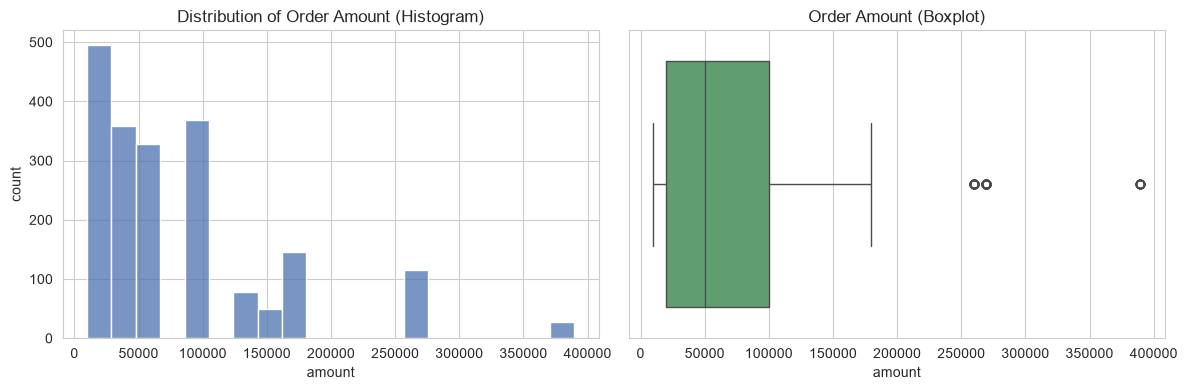

In [135]:
# [분포] 히스토그램 + 박스플롯 — 주문 금액은 어떻게 퍼져 있나?
amount_clean = orders["amount"].dropna()   # 결측 제외하고 시각화

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(amount_clean, bins=20, ax=axes[0], color="#4C72B0")
axes[0].set_title("Distribution of Order Amount (Histogram)")
axes[0].set_xlabel("amount"); axes[0].set_ylabel("count")

sns.boxplot(x=amount_clean, ax=axes[1], color="#55A868")
axes[1].set_title("Order Amount (Boxplot)")
axes[1].set_xlabel("amount")
plt.tight_layout(); plt.show()

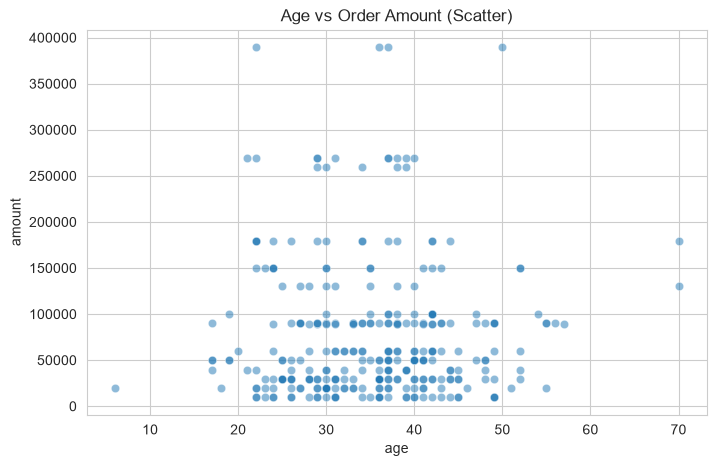

In [136]:
# [관계] 산점도 — 나이와 주문 금액은 관계가 있을까?
# customers와 orders를 customer_id로 연결(merge는 다음 모듈 주제, 여기선 맛만)
merged = orders.merge(customers[["customer_id", "age"]], on="customer_id", how="left")
sample = merged.dropna(subset=["amount"]).sample(300, random_state=42)

plt.figure(figsize=(8, 5))
sns.scatterplot(data=sample, x="age", y="amount", alpha=0.5)
plt.title("Age vs Order Amount (Scatter)")
plt.xlabel("age"); plt.ylabel("amount")
plt.show()

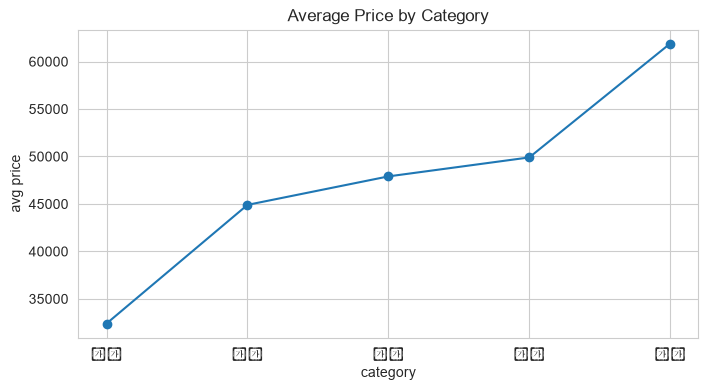

In [137]:
# [추이] 선 그래프 — 카테고리별 평균 가격 추이를 비교용으로
cat_price = products.groupby("category")["price"].mean().sort_values()

plt.figure(figsize=(8, 4))
plt.plot(cat_price.index, cat_price.values, marker="o")
plt.title("Average Price by Category")
plt.xlabel("category"); plt.ylabel("avg price")
plt.show()

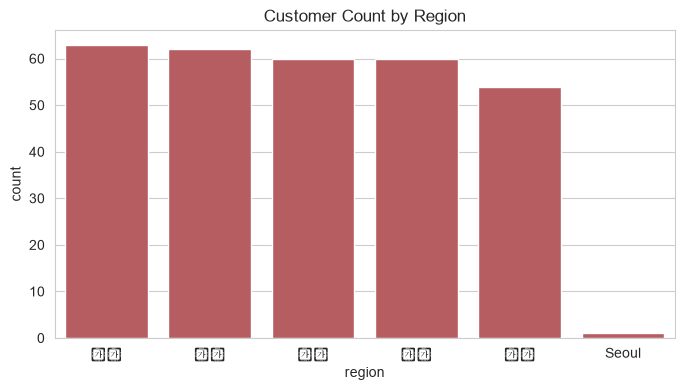

In [138]:
# [비교] 막대 그래프 — 지역별 고객 수 비교
# region 표기 혼재를 임시로 정리(공백 제거)해 비교만 합니다. 본격 정제는 다음 시간!
region_count = customers["region"].str.strip().value_counts()

plt.figure(figsize=(8, 4))
sns.barplot(x=region_count.index, y=region_count.values, color="#C44E52")
plt.title("Customer Count by Region")
plt.xlabel("region"); plt.ylabel("count")
plt.show()

In [139]:
import matplotlib.font_manager as fm
[f.name for f in fm.fontManager.ttflist if 'Gothic' in f.name or 'Apple' in f.name]

['Kim jung chul Gothic',
 'Kim jung chul Gothic Light',
 'Apple Braille',
 'Apple LiSung',
 'Apple Symbols',
 'Apple SD Gothic Neo',
 '.Apple SD Gothic NeoI',
 'Apple SD Gothic Neo',
 '.Apple SD Gothic NeoI',
 'Apple SD Gothic Neo',
 '.Apple SD Gothic NeoI',
 'Apple SD Gothic Neo',
 '.Apple SD Gothic NeoI',
 'Apple SD Gothic Neo',
 '.Apple SD Gothic NeoI',
 'Apple SD Gothic Neo',
 '.Apple SD Gothic NeoI',
 'Apple SD Gothic Neo',
 '.Apple SD Gothic NeoI',
 'Apple SD Gothic Neo',
 '.Apple SD Gothic NeoI',
 'Apple SD Gothic Neo',
 '.Apple SD Gothic NeoI',
 'Apple LiGothic',
 '.Hiragino Kaku Gothic Interface',
 'Hiragino Kaku Gothic Std',
 'Hiragino Kaku Gothic Std W8',
 'Hiragino Kaku Gothic StdN',
 'Hiragino Kaku Gothic StdN W8',
 '.Hiragino Kaku Gothic Interface',
 'League Gothic',
 'League Gothic Condensed',
 'Kim jung chul Gothic',
 'Kim jung chul Gothic Regular',
 '.Hiragino Kaku Gothic Interface',
 'Century Gothic Pro',
 'YoonA Gothic 700',
 'YoonA Gothic 750',
 '.Hiragino Kaku Goth

In [140]:
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False


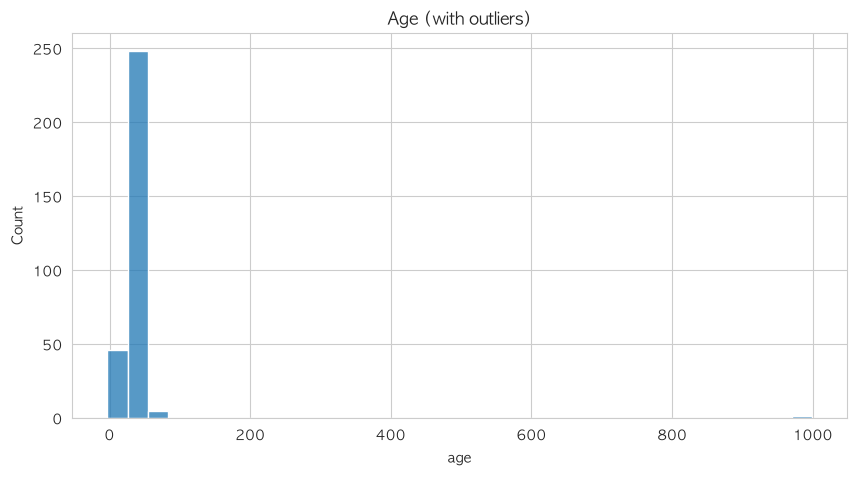

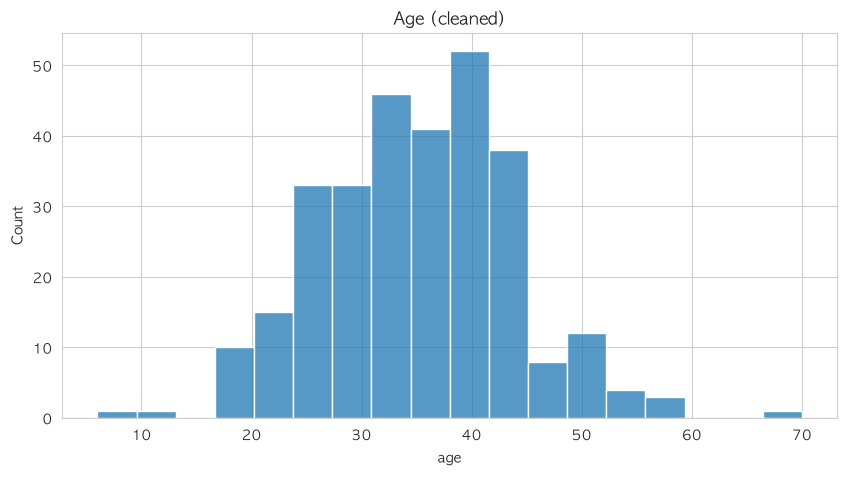

In [141]:
sns.histplot(customers["age"]); plt.title("Age (with outliers)"); plt.show()

mask = (customers["age"] > 0) & (customers["age"] < 120)
sns.histplot(customers.loc[mask, "age"]); plt.title("Age (cleaned)"); plt.show()


In [142]:
# 공공데이터 스타일 데이터 생성 (따릉이 일별 대여 기록 — 가상)
np.random.seed(7)
n_days = 180
dates = pd.date_range("2025-01-01", periods=n_days, freq="D")
# 계절성: 봄·여름에 대여 증가
seasonal = 3000 + 2500 * np.sin(np.linspace(0, np.pi, n_days))
rentals = (seasonal + np.random.normal(0, 400, n_days)).round().astype(int)

bike = pd.DataFrame({
    "date": dates,
    "rentals": rentals,
    "avg_temp": (np.linspace(-2, 28, n_days) + np.random.normal(0, 2, n_days)).round(1),
    "rainfall": np.random.choice([0, 0, 0, 0, 5, 12, 30], n_days),
    "station_area": np.random.choice(["강남", "마포", "송파", "종로", " 강남 "], n_days),
})
# 오염 심기: 대여수 결측, 기온 이상치, 중복 행
bike.loc[np.random.choice(n_days, 8, replace=False), "rentals"] = np.nan
bike.loc[50, "avg_temp"] = 250.0     # 센서 오류로 보이는 이상치
bike = pd.concat([bike, bike.iloc[[3]]], ignore_index=True)  # 중복 1건

print("따릉이 데이터 준비 완료:", bike.shape)
bike.head()

따릉이 데이터 준비 완료: (181, 5)


,date,rentals,avg_temp,rainfall,station_area
0,2025-01-01,3676.0,-3.0,12,마포
1,2025-01-02,2857.0,-1.1,0,마포
2,2025-01-03,3101.0,-1.1,0,강남
3,2025-01-04,3295.0,0.9,0,강남
4,2025-01-05,2860.0,-1.1,0,마포


In [143]:
# 시나리오 1 — 구조 진단
print("shape:", bike.shape)
bike.info()
display(bike.describe())

shape: (181, 5)
<class 'pandas.DataFrame'>
RangeIndex: 181 entries, 0 to 180
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          181 non-null    datetime64[us]
 1   rentals       173 non-null    float64       
 2   avg_temp      181 non-null    float64       
 3   rainfall      181 non-null    int64         
 4   station_area  181 non-null    str           
dtypes: datetime64[us](1), float64(2), int64(1), str(1)
memory usage: 7.2 KB


,date,rentals,avg_temp,rainfall
count,181,173.000000,181.000000,181.000000
mean,2025-03-31 00:31:49.392265,4531.757225,14.169061,5.298343
min,2025-01-01 00:00:00,2514.000000,-4.900000,0.000000
25%,2025-02-14 00:00:00,3841.000000,5.100000,0.000000
50%,2025-03-31 00:00:00,4708.000000,13.100000,0.000000
75%,2025-05-15 00:00:00,5243.000000,20.600000,5.000000
max,2025-06-29 00:00:00,6388.000000,250.000000,30.000000
std,NaN,889.609013,19.742786,9.687303


In [144]:
# 시나리오 2 — 품질 진단
print("[결측치]")
print(bike.isnull().sum())
print("\n중복 행:", bike.duplicated().sum())
print("\n[station_area 값의 종류]")
print(bike["station_area"].unique())
print("\n기온 이상치 확인(상위 3개):")
print(bike["avg_temp"].sort_values(ascending=False).head(3).tolist())

[결측치]
date            0
rentals         8
avg_temp        0
rainfall        0
station_area    0
dtype: int64

중복 행: 1

[station_area 값의 종류]
<StringArray>
['마포', ' 강남 ', '강남', '송파', '종로']
Length: 5, dtype: str

기온 이상치 확인(상위 3개):
[250.0, 31.8, 30.6]


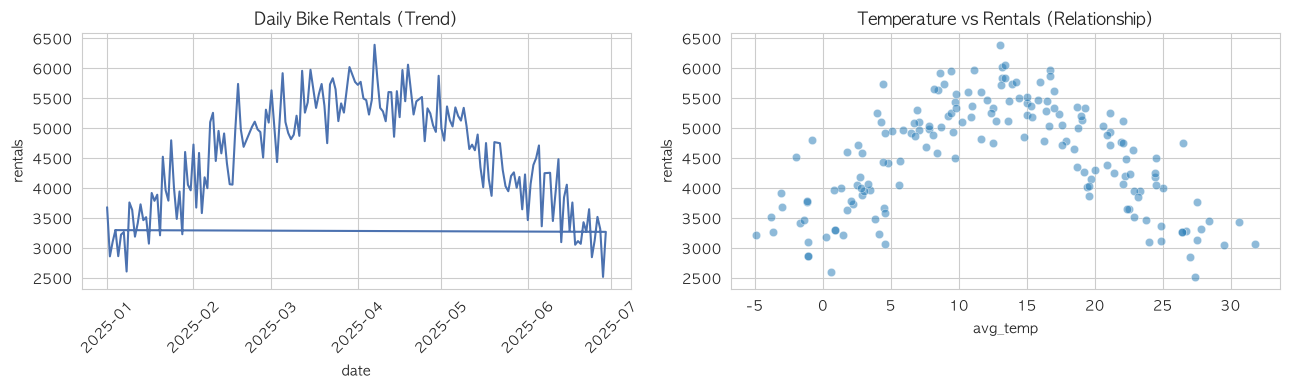

In [145]:
# 시나리오 3 — 시각화 (이상치 제거 후)
clean = bike[(bike["avg_temp"] < 60)].dropna(subset=["rentals"])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
# 추이
axes[0].plot(clean["date"], clean["rentals"], color="#4C72B0")
axes[0].set_title("Daily Bike Rentals (Trend)")
axes[0].set_xlabel("date"); axes[0].set_ylabel("rentals")
axes[0].tick_params(axis="x", rotation=45)
# 관계
sns.scatterplot(data=clean, x="avg_temp", y="rentals", alpha=0.5, ax=axes[1])
axes[1].set_title("Temperature vs Rentals (Relationship)")
axes[1].set_xlabel("avg_temp"); axes[1].set_ylabel("rentals")
plt.tight_layout(); plt.show()

In [146]:
# 코드 퀴즈 — 모범 답안
cond = (orders["channel"] == "web") & (orders["amount"].notna())
web_valid = orders[cond]

print("조건을 만족하는 주문 건수:", len(web_valid))
print("평균 금액:", round(web_valid["amount"].mean(), 1))

조건을 만족하는 주문 건수: 858
평균 금액: 79019.8


## 마무리 EDA 리포트 — 따릉이 대여 데이터

### 1. 데이터 개요
- 기간: 2025-01-01 ~ 2025-06-29
- 주요 컬럼: - 주요 컬럼: date(날짜), rentals(대여건수), avg_temp(평균기온), rainfall(강수량), station_area(대여소 지역)

### 2. 구조 진단 (shape / info / describe)
- 자료형: date는 datetime, rentals·avg_temp는 float, rainfall은 int, station_area는 str
- 수치 요약에서 눈에 띈 점: avg_temp 최댓값 250 → 센서 오류로 보이는 이상치, rentals 평균 4531 (정상 범위)

### 3. 품질 진단 (결측 / 중복 / 표기)
- 결측: rentals 8건
- 중복: 1건
- 표기 혼재: station_area에 ' 강남 '(공백 포함)과 '강남'이 별도 값으로 존재

### 4. 패턴 (시각화에서 읽은 것)
- 추이: 1~4월까지 대여수 증가, 4월 정점 이후 5~6월 감소 (계절성)
- 관계: 기온과 대여수는 선형이 아닌 역U자 형태 — 10~15도 부근에서 최대, 너무 춥거나(0도 이하) 더우면(25도 이상) 감소

### 5. 다음 분석 제안
- rainfall(강수량)과 rentals의 관계를 추가로 확인하고 싶다
- avg_temp의 이상치(250)는 센서 오류로 판단, 전후 날짜 평균값으로 대체하는 방법을 고려
